In [1]:
import tensorflow as tf
from tensorflow import keras

from nn.alice import dataset, model
from physics.hstar import gghzz, c6
from physics.simulation import msq
from physics.analysis import zpair, angles

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import hist

from sklearn.preprocessing import MinMaxScaler

2025-01-15 16:04:05.704656: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-15 16:04:05.704692: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-15 16:04:05.704722: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-15 16:04:05.712997: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
SEED=373485

BASE_SIZE=100000

OUTPUT_DIR='jobs/alice/run-two-bce'
CONF_FILE='alice-config.json'
SCALER_CONF='scaler.json'
SAMPLE_DIR='..'

In [3]:
with open(os.path.join(OUTPUT_DIR, CONF_FILE), 'r') as conf_file:
    config = json.load(conf_file)

In [4]:
sample_train = gghzz.Process(msq.Component.SIG, (0.1, os.path.join(SAMPLE_DIR, 'ggZZ2e2m_sig.csv'), 1.2*BASE_SIZE))
sample_val = gghzz.Process(msq.Component.SIG, (0.1, os.path.join(SAMPLE_DIR, 'ggZZ2e2m_sig.csv'), config['num_events'] + 1.2*BASE_SIZE))
sample_val.events = sample_val.events[config['num_events']:]

In [5]:
z_chooser = zpair.ZPairChooser(bounds1=(70,115), bounds2=(70,115), algorithm='leastsquare')
kin_vars_train = angles.calculate_2(*sample_train.events.filter(z_chooser))
kin_vars_val = angles.calculate_2(*sample_val.events.filter(z_chooser))

sample_train.events = sample_train.events[:BASE_SIZE]
kin_vars_train = kin_vars_train[:BASE_SIZE]
sample_val.events = sample_val.events[:BASE_SIZE]
kin_vars_val = kin_vars_val[:BASE_SIZE]

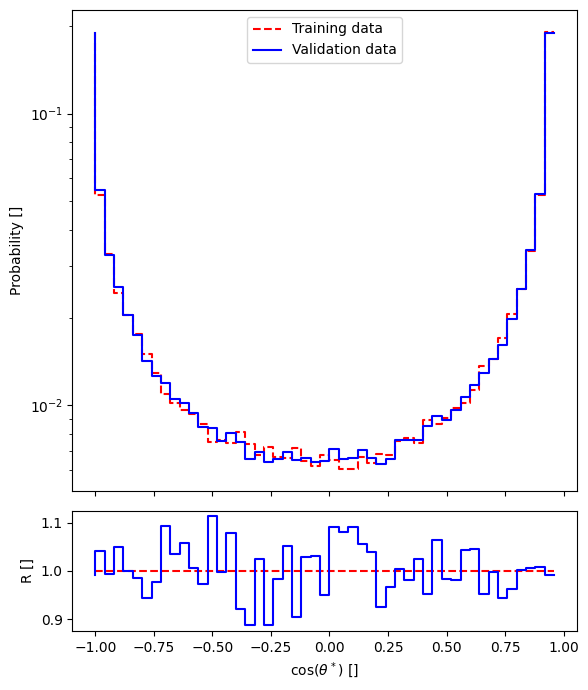

In [7]:
cth_str_train = kin_vars_train[:,0]
cth_str_val = kin_vars_val[:,0]

BINS=50

hist_train, bins = np.histogram(cth_str_train, bins=BINS, range=(-1,1), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(cth_str_val, bins=BINS, range=(-1,1), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$\mathrm{cos}(\\theta^*)$ []')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

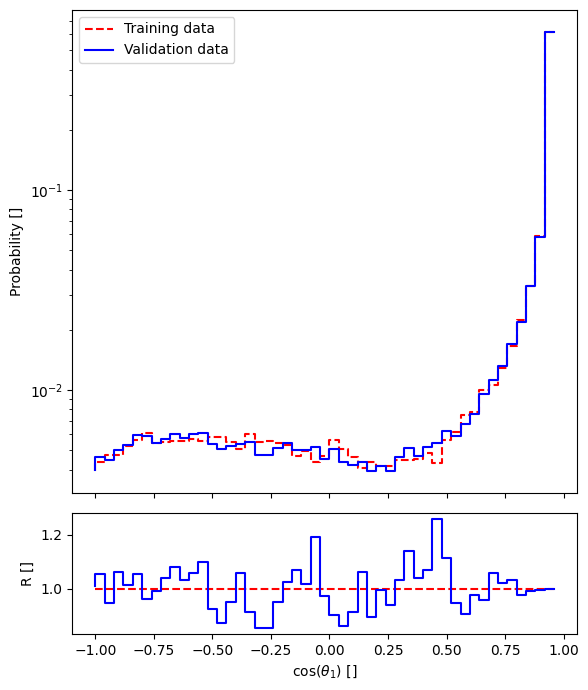

In [8]:
cth_1_train = kin_vars_train[:,1]
cth_1_val = kin_vars_val[:,1]

BINS=50

hist_train, bins = np.histogram(cth_1_train, bins=BINS, range=(-1,1), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(cth_1_val, bins=BINS, range=(-1,1), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$\mathrm{cos}(\\theta_1)$ []')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

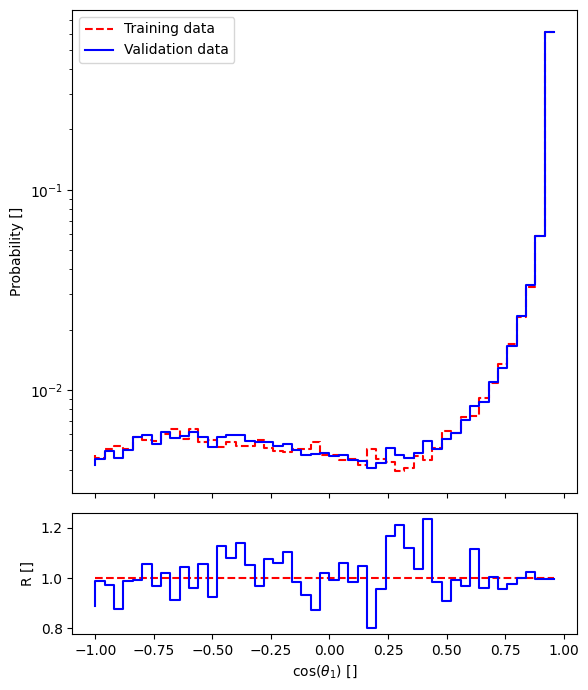

In [9]:
cth_2_train = kin_vars_train[:,2]
cth_2_val = kin_vars_val[:,2]

BINS=50

hist_train, bins = np.histogram(cth_2_train, bins=BINS, range=(-1,1), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(cth_2_val, bins=BINS, range=(-1,1), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$\mathrm{cos}(\\theta_1)$ []')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

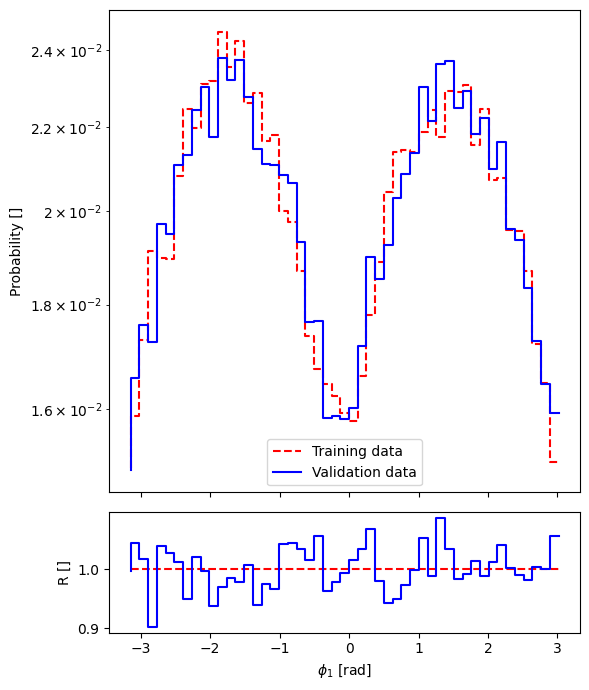

In [26]:
phi_1_train = kin_vars_train[:,3]
phi_1_val = kin_vars_val[:,3]

BINS=50

hist_train, bins = np.histogram(phi_1_train, bins=BINS, range=(-np.pi,np.pi), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(phi_1_val, bins=BINS, range=(-np.pi,np.pi), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$\\phi_1$ [rad]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

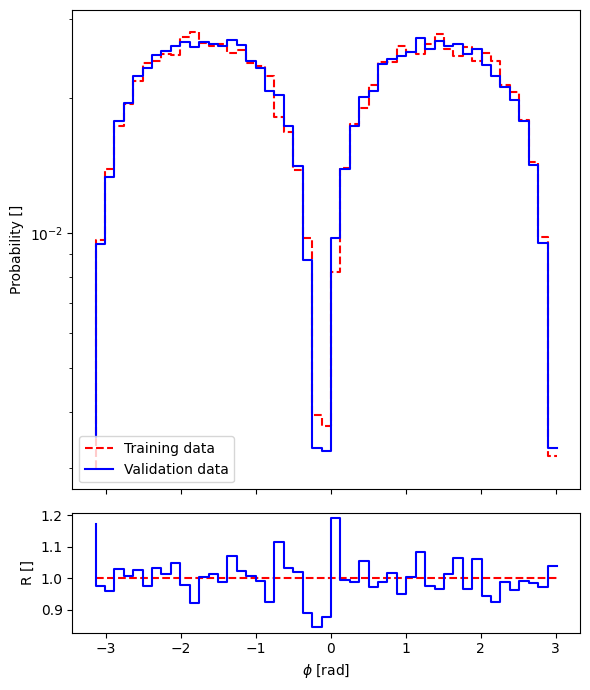

In [25]:
phi_train = kin_vars_train[:,4]
phi_val = kin_vars_val[:,4]

BINS=50

hist_train, bins = np.histogram(phi_train, bins=BINS, range=(-np.pi,np.pi), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(phi_val, bins=BINS, range=(-np.pi,np.pi), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$\phi$ [rad]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

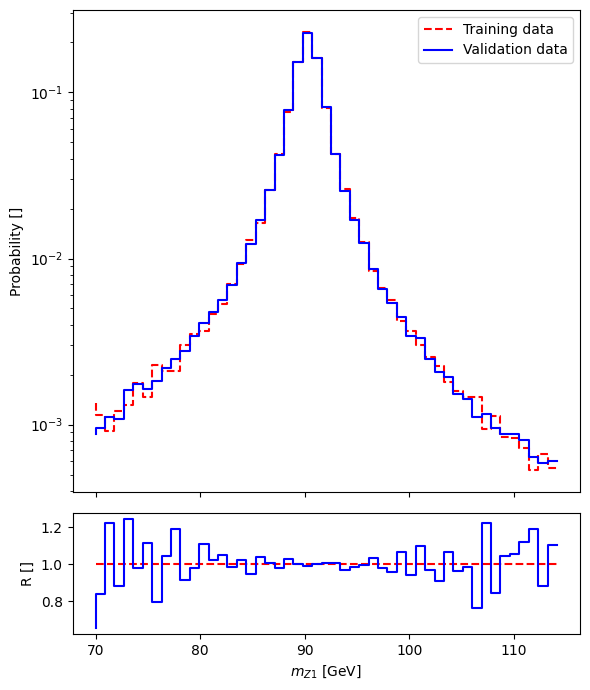

In [24]:
mZ1_train = kin_vars_train[:,5]
mZ1_val = kin_vars_val[:,5]

BINS=50

hist_train, bins = np.histogram(mZ1_train, bins=BINS, range=(70,115), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(mZ1_val, bins=BINS, range=(70,115), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$m_{Z1}$ [GeV]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

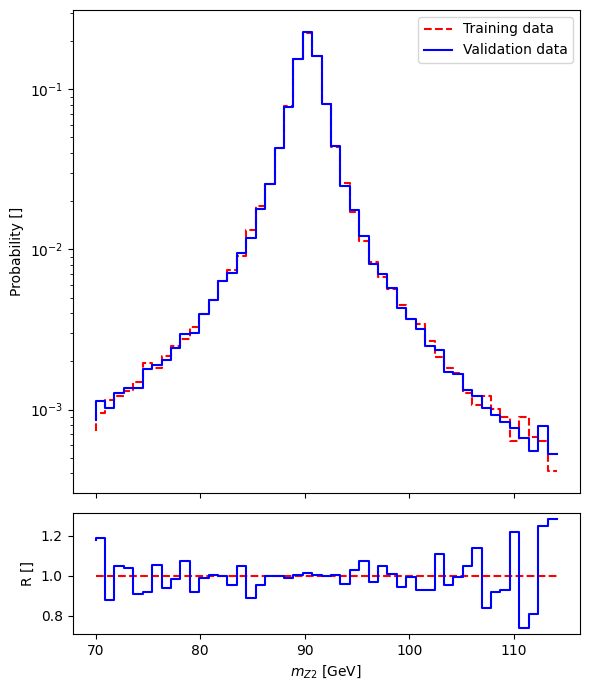

In [23]:
mZ2_train = kin_vars_train[:,6]
mZ2_val = kin_vars_val[:,6]

BINS=50

hist_train, bins = np.histogram(mZ2_train, bins=BINS, range=(70,115), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(mZ2_val, bins=BINS, range=(70,115), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$m_{Z2}$ [GeV]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

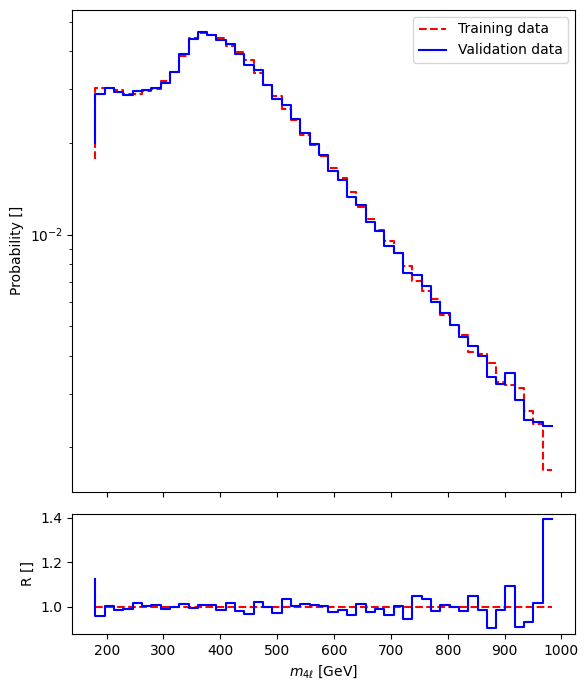

In [22]:
m4l_train = kin_vars_train[:,7]
m4l_val = kin_vars_val[:,7]

BINS=50

hist_train, bins = np.histogram(m4l_train, bins=BINS, range=(180,1000), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(m4l_val, bins=BINS, range=(180,1000), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$m_{4\ell}$ [GeV]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

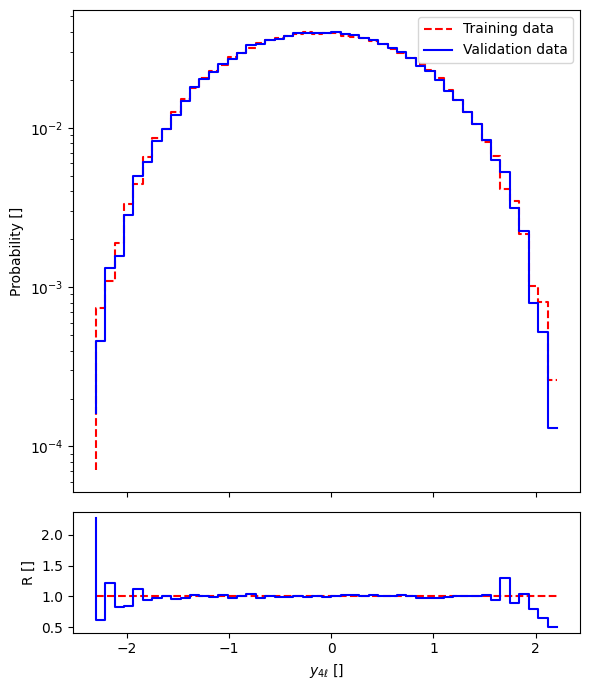

In [37]:
y4l_train = kin_vars_train[:,8]
y4l_val = kin_vars_val[:,8]

BINS=50

hist_train, bins = np.histogram(y4l_train, bins=BINS, range=(-2.3,2.3), weights=sample_train[msq.Component.SIG].probabilities)
hist_val, bins = np.histogram(y4l_val, bins=BINS, range=(-2.3,2.3), weights=sample_val[msq.Component.SIG].probabilities)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_train, color='r', linestyle='--', label=u'Training data')
ax1.step(bins[:-1], hist_val, color='b', label=u'Validation data')

ax1.set_ylabel('Probability []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_train/hist_train, color='r', linestyle='--', label=u'Training data')
ax2.step(bins[:-1], hist_val/hist_train, color='b', label=u'Validation data')

ax2.set_xlabel(u'$y_{4\ell}$ []')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()